# Per-plant model F1 — 2-panel map (U.S. + Global)

Paper-revision update of the F1 geographic figure. Loads the **new** trained
MLPs (`best_model_all_data_filtered{,_yearly}.pt` + scaler) from the latest
training runs, computes per-plant F1 on each plant's test split, then plots.

Cell layout:
1. Imports + paths
2. Compute per-plant F1 (U.S.) using new training output
3. Compute per-plant F1 (Global)
4. Plot the 2-panel map

Run after the new training jobs (`training_no_stats_item/`) have finished.

In [11]:
import os, sys, joblib, numpy as np, pandas as pd, torch
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

sys.path.insert(0, '/net/fs06/d3/rzhuang/TROPOMI/code')
from config import TRAINING
from shared.features import get_feature_list
from shared.model    import MLP
from shared.interference import (identify_interference_us_by_year,
                                 identify_interference_world,
                                 extract_year_from_datetime)

plt.rcdefaults()
plt.rcParams['font.size']        = 14
plt.rcParams['figure.facecolor'] = 'white'

# Register Nimbus Roman with matplotlib's font manager so we can refer to it
# by name in rcParams. setting `font.family = 'Nimbus Roman'` directly fails
# silently and emits hundreds of warnings if the .otf isn't registered.
nimbus_path = None
for _p in fm.findSystemFonts():
    _pl = _p.lower()
    if ('nimbusroman' in _pl or 'nimbus_roman' in _pl) \
            and 'bold' not in _pl and 'italic' not in _pl and 'oblique' not in _pl:
        nimbus_path = _p; break
if nimbus_path:
    fm.fontManager.addfont(nimbus_path)
    plt.rcParams['font.family'] = fm.FontProperties(fname=nimbus_path).get_name()
    print('Registered:', plt.rcParams['font.family'], '->', nimbus_path)
else:
    print('Nimbus Roman not found; using matplotlib default')

# ─── Paths ──────────────────────────────────────────────────────────────
US_HOURLY_CSV   = '/net/fs06/d3/rzhuang/TROPOMI/pipeline_100m_run/Run_100m_20260414/updated_tropomi_hourly_emissions_full_variables_augmented_localtz.csv'
US_FACILITY_CSV = '/net/fs06/d3/rzhuang/TROPOMI/data/us/facility_emissions_by_plant_comprehensive.csv'
US_ANNUAL_CSV   = '/net/fs06/d3/rzhuang/TROPOMI/data/us/annual-emissions-facility-aggregation-2019-2024.csv'
US_TRAIN_DIR    = '/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/training_no_stats_item'

WORLD_EMIT_CSV   = '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/updated_tropomi_emissions_full_variables_with_fuel_100mlabel.csv'
WORLD_LOC_CSV    = '/net/fs06/d3/rzhuang/TROPOMI/data/world/power_plant_location/power_plants_with_combined_nearby_stats.csv'
WORLD_CITIES_CSV = '/net/fs06/d3/rzhuang/TROPOMI/data/world/worldcities.csv'
WORLD_TRAIN_DIR  = '/net/fs06/d3/rzhuang/TROPOMI/data/world/pipeline_test_labelling_100m/Run_100m_20260428/training_no_stats_item'

OUT_DIR = '/net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures'
os.makedirs(OUT_DIR, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)


Registered: ['Nimbus Roman'] -> /usr/share/fonts/urw-base35/NimbusRoman-Regular.otf
device: cpu


In [12]:
# ─── Helper: replicate train_mlp.py's filter + item split, then run
#     inference per plant ────────────────────────────────────────────────
def per_plant_metrics(test_df, X_test_scaled, y_test, model):
    """For each plant in `test_df` (already aligned with X_test_scaled rows),
    compute F1, accuracy, AUC over that plant's test observations."""
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(torch.from_numpy(X_test_scaled.astype(np.float32)).to(device))).cpu().numpy()
    preds = (probs >= TRAINING['prediction_threshold']).astype(int)
    test_df = test_df.assign(_pred=preds, _prob=probs, _y=y_test).copy()

    rows = []
    for loc, g in test_df.groupby('location'):
        if g['_y'].nunique() < 2:  # AUC undefined; still report f1/acc
            auc_v = float('nan')
        else:
            try:
                auc_v = roc_auc_score(g['_y'], g['_prob'])
            except Exception:
                auc_v = float('nan')
        f1_v = f1_score(g['_y'], g['_pred'], zero_division=0)
        acc_v = (g['_y'] == g['_pred']).mean()
        rows.append({
            'location': loc,
            'n_obs': len(g),
            'pos_rate': float(g['_y'].mean()),
            'f1': float(f1_v),
            'auc': float(auc_v) if pd.notna(auc_v) else float('nan'),
            'accuracy': float(acc_v),
        })
    return pd.DataFrame(rows)

In [13]:
# ─── 2. U.S.: filter to 171-plant set, item-split, run model on test ──
print('Loading U.S. snapshots...')
tropomi = pd.read_csv(US_HOURLY_CSV).dropna()
tropomi = extract_year_from_datetime(tropomi)
tropomi['primary_fuel_type'] = LabelEncoder().fit_transform(tropomi['primary_fuel_type'])

plants  = pd.read_csv(US_FACILITY_CSV).sort_values('NOx_Rank', ascending=True)
annual  = pd.read_csv(US_ANNUAL_CSV)
cities  = pd.read_csv(WORLD_CITIES_CSV)

top500 = plants.head(500)['Facility_ID'].tolist()
US_YEARS = [2019, 2020, 2021, 2022, 2023, 2024]
emis_top = annual[annual['Facility ID'].isin(top500)]
present_yrs = (emis_top[emis_top['Year'].isin(US_YEARS)]
               .groupby('Facility ID')['Year'].nunique())
complete_6y_ids = set(present_yrs[present_yrs == len(US_YEARS)].index)

pdf_strict  = plants[plants['Facility_ID'].isin(complete_6y_ids)]
emis_strict = emis_top[emis_top['Facility ID'].isin(complete_6y_ids)]
interf = identify_interference_us_by_year(pdf_strict, emis_strict, cities,
                                            plant_subset_ids=list(complete_6y_ids))
ever_interfered = set().union(*[set(v) for v in interf.values()])
kept_ids = complete_6y_ids - ever_interfered
print(f'U.S. kept plants (paper 171 recipe): {len(kept_ids)}')

ds = tropomi[tropomi['location'].isin(kept_ids)].reset_index(drop=True)
feats = get_feature_list('no_stats', 'us', 'hourly')
X = ds[feats].values.astype(np.float32)
y = ds['plume_label'].astype(int).values

# Replicate train_mlp.py:_split_item run-0 (seed=345 then 346)
seed = TRAINING['split_seed_sweep']
val_r, test_r = TRAINING['val_ratio'], TRAINING['test_ratio']
pos = np.arange(len(ds))
pos_tt, pos_val = train_test_split(pos, test_size=val_r, random_state=seed)
rel_te = test_r / (1 - val_r)
_, pos_te_in_tt = train_test_split(np.arange(len(pos_tt)), test_size=rel_te, random_state=seed + 1)
test_idx = pos_tt[pos_te_in_tt]
test_ds = ds.iloc[test_idx].reset_index(drop=True)
X_test = X[test_idx]; y_test = y[test_idx]
print(f'U.S. test set: {len(test_ds):,} obs across {test_ds["location"].nunique()} plants')

scaler = joblib.load(os.path.join(US_TRAIN_DIR, 'best_scaler_all_data_filtered_yearly.pkl'))
X_test_s = scaler.transform(X_test)
model = MLP(X.shape[1]).to(device)
model.load_state_dict(torch.load(
    os.path.join(US_TRAIN_DIR, 'best_model_all_data_filtered_yearly.pt'),
    map_location=device))
us_per_plant = per_plant_metrics(test_ds, X_test_s, y_test, model)

# Merge with plant metadata for lat/lon/emission
us_meta = plants[['Facility_ID', 'Latitude', 'Longitude', 'Total_NOx_Mass']].copy()
us_meta = us_meta.rename(columns={'Facility_ID': 'location'})
us_per_plant = us_per_plant.merge(us_meta, on='location', how='left')
us_per_plant.to_csv(os.path.join(OUT_DIR, 'per_plant_performance_us.csv'), index=False)
print(f'U.S. per-plant: {len(us_per_plant)} plants  -> per_plant_performance_us.csv')
print(f'  F1 mean={us_per_plant["f1"].mean():.3f}  median={us_per_plant["f1"].median():.3f}')

Loading U.S. snapshots...
Identifying plants in interference zones by year...
Year 2019: 283 interfered / 460 plants
Year 2020: 283 interfered / 460 plants
Year 2021: 283 interfered / 460 plants
Year 2022: 283 interfered / 460 plants
Year 2023: 283 interfered / 460 plants
Year 2024: 283 interfered / 460 plants
U.S. kept plants (paper 171 recipe): 171
U.S. test set: 37,943 obs across 171 plants
U.S. per-plant: 171 plants  -> per_plant_performance_us.csv
  F1 mean=0.449  median=0.460


In [14]:
# ─── 3. Global: same recipe, world filter ─────────────────────────────
print('Loading global snapshots...')
tw = pd.read_csv(WORLD_EMIT_CSV).dropna(subset=get_feature_list('no_stats','world') + ['plume_label','location'])
tw['primary_fuel_type'] = LabelEncoder().fit_transform(tw['primary_fuel_type'])

wp = pd.read_csv(WORLD_LOC_CSV)
if 'annual_nox_emission' in wp.columns:
    wp = wp.sort_values('annual_nox_emission', ascending=False)
all_world_ids = tw['location'].unique().tolist()
interf_w = identify_interference_world(wp, cities, plant_subset_ids=all_world_ids)
kept_world = set(all_world_ids) - set(interf_w)
print(f'World kept plants after interference: {len(kept_world)}')

dsw = tw[tw['location'].isin(kept_world)].reset_index(drop=True)
featsw = get_feature_list('no_stats', 'world', 'annual')
Xw = dsw[featsw].values.astype(np.float32)
yw = dsw['plume_label'].astype(int).values
posw = np.arange(len(dsw))
posw_tt, posw_val = train_test_split(posw, test_size=val_r, random_state=seed)
_, posw_te_in_tt = train_test_split(np.arange(len(posw_tt)), test_size=rel_te, random_state=seed + 1)
testw_idx = posw_tt[posw_te_in_tt]
testw_ds = dsw.iloc[testw_idx].reset_index(drop=True)
Xw_test = Xw[testw_idx]; yw_test = yw[testw_idx]
print(f'World test set: {len(testw_ds):,} obs across {testw_ds["location"].nunique()} plants')

scalerw = joblib.load(os.path.join(WORLD_TRAIN_DIR, 'best_scaler_all_data_filtered.pkl'))
Xw_test_s = scalerw.transform(Xw_test)
modelw = MLP(Xw.shape[1]).to(device)
modelw.load_state_dict(torch.load(
    os.path.join(WORLD_TRAIN_DIR, 'best_model_all_data_filtered.pt'),
    map_location=device))
world_per_plant = per_plant_metrics(testw_ds, Xw_test_s, yw_test, modelw)

world_meta = wp.rename(columns={'ID': 'location'})[['location', 'latitude', 'longitude', 'nox_emis_ty']]
world_per_plant = world_per_plant.merge(world_meta, on='location', how='left')
world_per_plant.to_csv(os.path.join(OUT_DIR, 'per_plant_performance_world.csv'), index=False)
print(f'World per-plant: {len(world_per_plant)} plants  -> per_plant_performance_world.csv')
print(f'  F1 mean={world_per_plant["f1"].mean():.3f}  median={world_per_plant["f1"].median():.3f}')

Loading global snapshots...
Identifying plants in interference zones (global)...


Checking interference: 100%|██████████| 6000/6000 [00:03<00:00, 1864.57it/s]


Found 4935 interfered / 6000 plants
World kept plants after interference: 1065
World test set: 32,224 obs across 1065 plants
World per-plant: 1065 plants  -> per_plant_performance_world.csv
  F1 mean=0.403  median=0.400


Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/Model_F1_Geographic_Map.pdf
Saved: /net/fs06/d3/rzhuang/TROPOMI/data/us/Run_100m_20260414/paper_figures/Model_F1_Geographic_Map.png


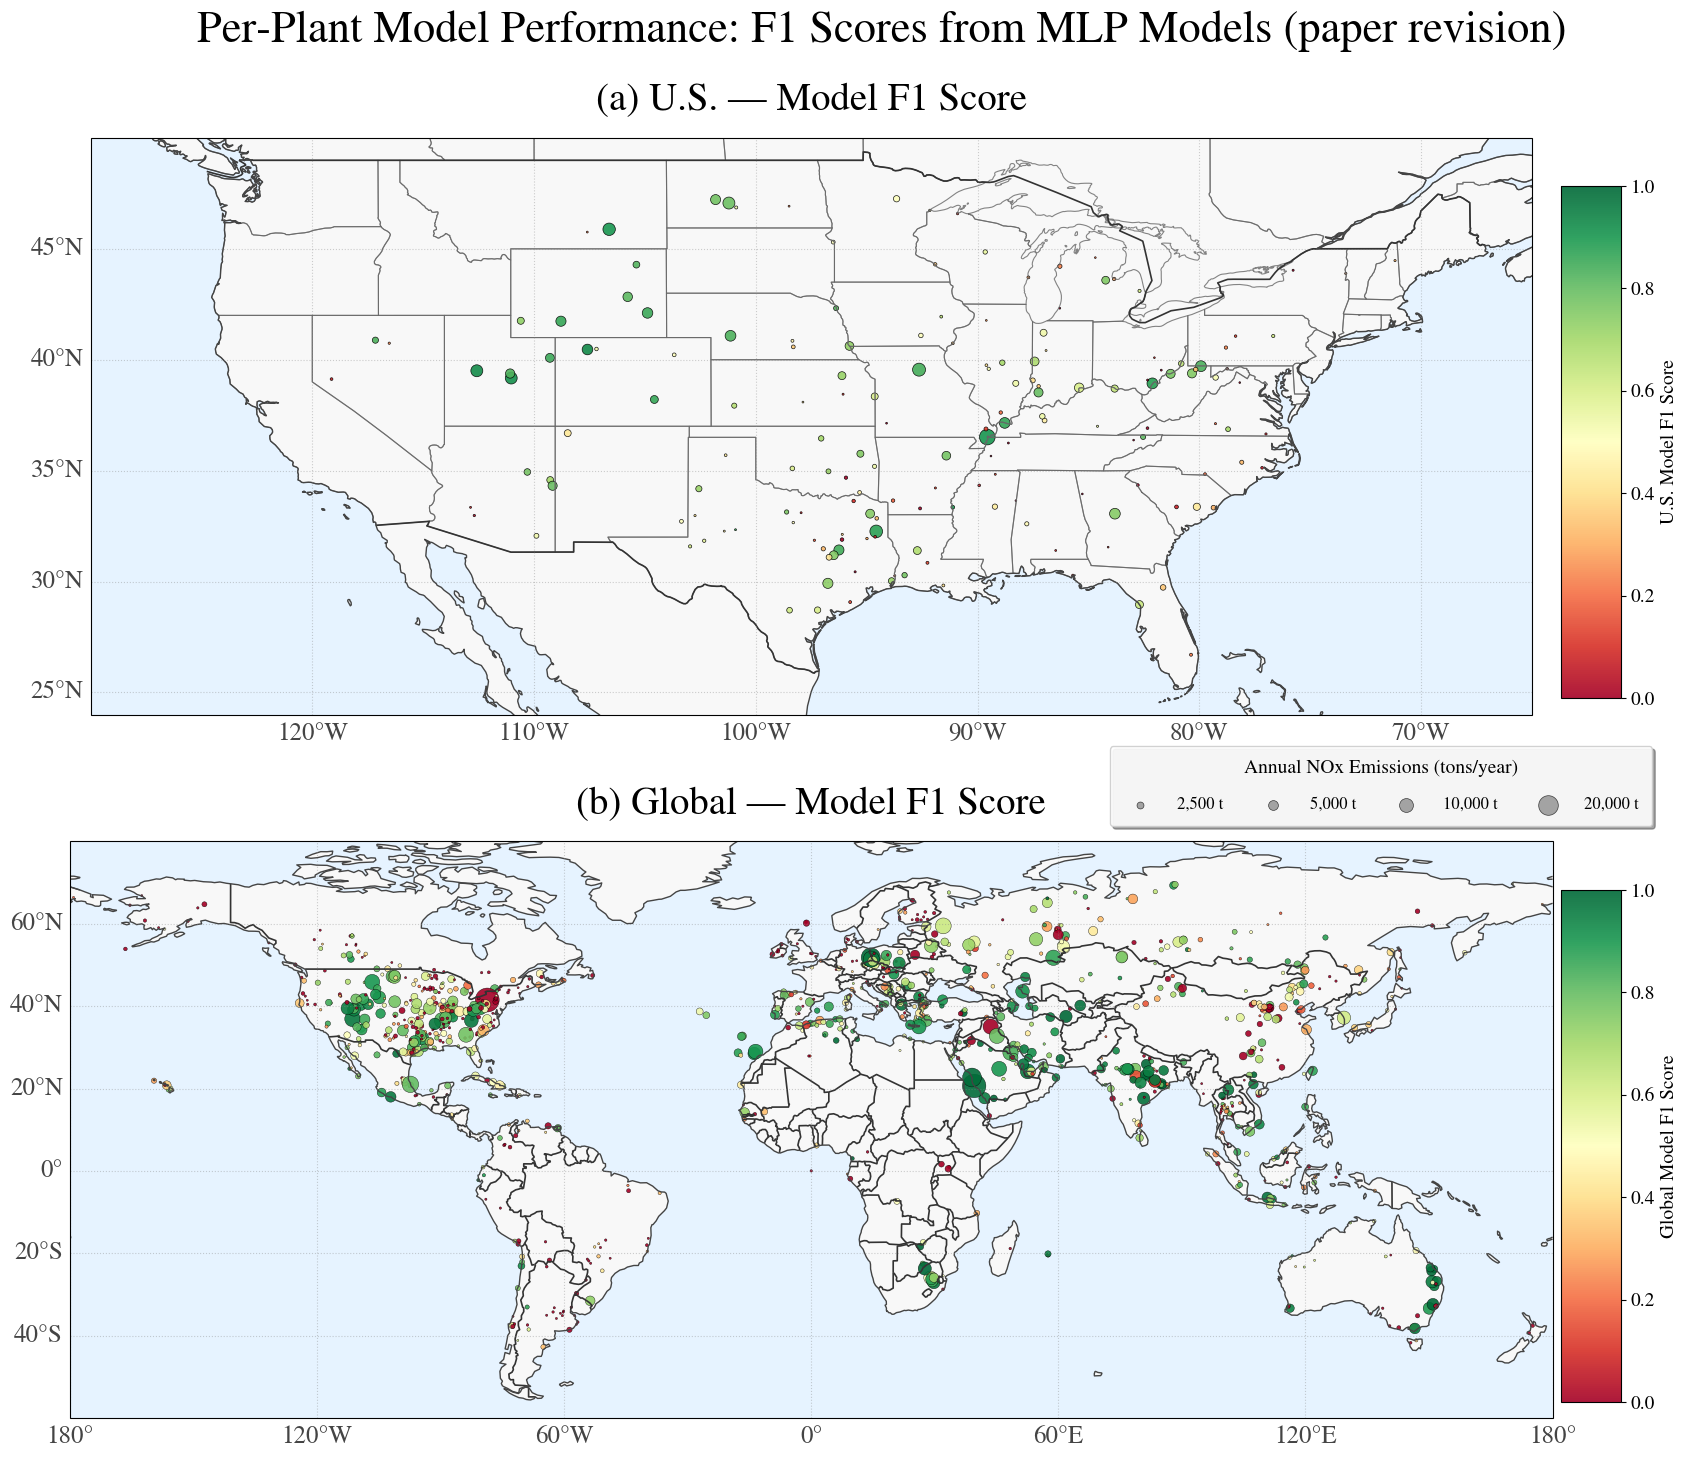

In [15]:
# ─── 4. Plot 2-panel F1 map (mirrors paper figure) ────────────────────
us_gdf = gpd.GeoDataFrame(
    us_per_plant.dropna(subset=['Latitude','Longitude','f1']),
    geometry=gpd.points_from_xy(us_per_plant.dropna(subset=['Latitude','Longitude','f1'])['Longitude'],
                                 us_per_plant.dropna(subset=['Latitude','Longitude','f1'])['Latitude']),
    crs='EPSG:4326')
world_gdf = gpd.GeoDataFrame(
    world_per_plant.dropna(subset=['latitude','longitude','f1']),
    geometry=gpd.points_from_xy(world_per_plant.dropna(subset=['latitude','longitude','f1'])['longitude'],
                                 world_per_plant.dropna(subset=['latitude','longitude','f1'])['latitude']),
    crs='EPSG:4326')

nox_scaling_factor = 0.01
us_gdf['NOx_mass_scaled']    = us_gdf['Total_NOx_Mass'] * 0.907185 / 6 * nox_scaling_factor
world_gdf['NOx_mass_scaled'] = world_gdf['nox_emis_ty'] * nox_scaling_factor

fig = plt.figure(figsize=(20, 16))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.22,
                      top=0.88, bottom=0.08, left=0.05, right=0.88)
fig.suptitle('Per-Plant Model Performance: F1 Scores from MLP Models (paper revision)',
             fontsize=32, y=0.96, weight='bold')

def style_us_map(ax, title):
    ax.set_extent([-130, -65, 24, 50], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,  facecolor='#f8f8f8', edgecolor='none')
    ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
    ax.add_feature(cfeature.STATES,  linewidth=0.8, edgecolor='#666666', alpha=0.8)
    ax.add_feature(cfeature.BORDERS, linewidth=1.2, edgecolor='#333333')
    ax.coastlines(linewidth=1.0, color='#444444')
    gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.4, linewidth=0.8, color='#888888')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 18, 'color': '#444444'}
    gl.ylabel_style = {'size': 18, 'color': '#444444'}
    ax.set_title(title, fontsize=28, fontweight='bold', pad=20)

def style_global_map(ax, title):
    ax.set_extent([-180, 180, -60, 80], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.LAND,  facecolor='#f8f8f8', edgecolor='none')
    ax.add_feature(cfeature.OCEAN, facecolor='#e6f3ff')
    ax.add_feature(cfeature.BORDERS, linewidth=1.2, edgecolor='#333333')
    ax.coastlines(linewidth=1.0, color='#444444')
    gl = ax.gridlines(draw_labels=True, linestyle=':', alpha=0.4, linewidth=0.8, color='#888888')
    gl.top_labels = False; gl.right_labels = False
    gl.xlabel_style = {'size': 18, 'color': '#444444'}
    gl.ylabel_style = {'size': 18, 'color': '#444444'}
    ax.set_title(title, fontsize=28, fontweight='bold', pad=20)

norm_f1 = mcolors.Normalize(vmin=0, vmax=1)

ax1 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
style_us_map(ax1, '(a) U.S. \u2014 Model F1 Score')
sc1 = ax1.scatter(us_gdf['Longitude'], us_gdf['Latitude'],
                  s=us_gdf['NOx_mass_scaled'], c=us_gdf['f1'],
                  cmap='RdYlGn', norm=norm_f1, alpha=0.9, marker='o',
                  edgecolors='black', linewidths=0.5,
                  transform=ccrs.PlateCarree())

ax2 = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
style_global_map(ax2, '(b) Global \u2014 Model F1 Score')
sc2 = ax2.scatter(world_gdf['longitude'], world_gdf['latitude'],
                  s=world_gdf['NOx_mass_scaled'], c=world_gdf['f1'],
                  cmap='RdYlGn', norm=norm_f1, alpha=0.9, marker='o',
                  edgecolors='black', linewidths=0.3,
                  transform=ccrs.PlateCarree())

cbar_ax1 = fig.add_axes([0.84, 0.53, 0.03, 0.32])
fig.colorbar(sc1, cax=cbar_ax1, orientation='vertical').set_label('U.S. Model F1 Score', fontsize=14, fontweight='bold')
cbar_ax2 = fig.add_axes([0.84, 0.09, 0.03, 0.32])
fig.colorbar(sc2, cax=cbar_ax2, orientation='vertical').set_label('Global Model F1 Score', fontsize=14, fontweight='bold')

legend_sizes  = [25, 50, 100, 200]
legend_labels = [f'{int(s/nox_scaling_factor):,} t' for s in legend_sizes]
legend_handles = [plt.scatter([], [], s=s, c='gray', alpha=0.7,
                              edgecolors='black', linewidths=0.5) for s in legend_sizes]
leg = fig.legend(legend_handles, legend_labels, borderpad=0.8,
                 title='Annual NOx Emissions (tons/year)',
                 labelspacing=1.2, ncol=len(legend_handles),
                 loc='upper center', bbox_to_anchor=(0.75, 0.505),
                 fontsize=12, title_fontsize=14, frameon=True,
                 fancybox=True, shadow=True,
                 handletextpad=1.2, columnspacing=2)
leg.get_frame().set_facecolor('white'); leg.get_frame().set_alpha(0.9)

out_pdf = os.path.join(OUT_DIR, 'Model_F1_Geographic_Map.pdf')
out_png = os.path.join(OUT_DIR, 'Model_F1_Geographic_Map.png')
plt.savefig(out_pdf, dpi=300, bbox_inches='tight', facecolor='white')
plt.savefig(out_png, dpi=300, bbox_inches='tight', facecolor='white')
print(f'Saved: {out_pdf}')
print(f'Saved: {out_png}')
plt.show()